In [22]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from scipy.stats import linregress
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
import os
import re
import matplotlib as mpl

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

#add rc param for ticks are inwards and minor ticks are on
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)

cmap = cm.get_cmap('magma')


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_34135/3504773421.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('magma')


In [23]:
# load in the HII region catalog
cat_path = 'CATALOGS/flux_catalogs/total_flux_catalog.csv'
cat = pd.read_csv(cat_path)
# print all column names
for col in cat.columns:
    print(col)

region_id
npix_region
npix_edge_ring
F_Halpha_sum
F_Halpha_e_sum
SNR_Halpha_sum
Halpha_b_edge
F_Hbeta_sum
F_Hbeta_e_sum
SNR_Hbeta_sum
Hbeta_b_edge
F_[OIII]5007_sum
F_[OIII]5007_e_sum
SNR_[OIII]5007_sum
[OIII]5007_b_edge
F_[SII]6716_sum
F_[SII]6716_e_sum
SNR_[SII]6716_sum
[SII]6716_b_edge
F_[SII]6731_sum
F_[SII]6731_e_sum
SNR_[SII]6731_sum
[SII]6731_b_edge
F_[NII]6583_sum
F_[NII]6583_e_sum
SNR_[NII]6583_sum
[NII]6583_b_edge
F_[OII]3727_sum
F_[OII]3727_e_sum
SNR_[OII]3727_sum
[OII]3727_b_edge
field
y
x
removed_by_saddle
removed_by_edge
kind
center_x_px
center_y_px
zoi_center_label
bg_local
sigma_local
radius_p16_px
radius_p50_px
radius_p84_px
radius_p16_pc
radius_p50_pc
radius_p84_pc
radius_areaeq_px
radius_areaeq_pc
boundary_method
area_px_after_carve
radius_areaeq_px_after_carve
radius_areaeq_pc_after_carve
id_int
x_int
y_int
FIELD_int
F_[OII]3727_int
F_[OII]3727_e_int
SNR_[OII]3727_int
F_Hbeta_int
F_Hbeta_e_int
SNR_Hbeta_int
F_[OIII]4959_int
F_[OIII]4959_e_int
SNR_[OIII]4959_int
F_[OI

In [24]:
# load in the WR and SNR catalogs
wr_catalog = pd.read_csv('CATALOGS/WR_catalog.csv', sep='\t')
snr_catalog = pd.read_csv('CATALOGS/snr_table.csv')
rows = []
with open("CATALOGS/snr_table.csv", "r") as f:
    for line in f:
        # Remove LaTeX and dollar symbols
        clean = re.sub(r"\\rm|\\pm|\$", "", line)
        # Split by comma
        parts = [p.strip() for p in clean.split(",") if p.strip()]
        # Find any token that looks like an RA (contains colons) and a Dec (starts with + or -)
        ra, dec = None, None
        for p in parts:
            if ":" in p and ra is None:
                ra = p
            elif (p.startswith("+") or p.startswith("-")) and ":" in p and dec is None:
                dec = p
        if ra and dec:
            rows.append((ra, dec))

# Make a DataFrame
snr_catalog = pd.DataFrame(rows, columns=["RA", "Dec"])

In [25]:
def field_to_fieldnum(field_label: str) -> str:
    """
    Map your plot field labels to WR catalog Field codes.
    Input examples: 'NE','NW','SE','SW','F5'...'F9'
    Output: 'F1'...'F9'
    """
    mapping = {"NE": "F1", "NW": "F2", "SE": "F3", "SW": "F4"}
    return mapping.get(field_label, field_label)  # F5->F5 etc.


def parse_name_to_coords(name: str) -> SkyCoord:
    # Example: 'J013307.80+302951.1'
    ra_h = name[1:3]
    ra_m = name[3:5]
    ra_s = name[5:10]
    dec_sign = name[10]
    dec_d = name[11:13]
    dec_m = name[13:15]
    dec_s = name[15:]
    ra_str = f"{ra_h}h{ra_m}m{ra_s}s"
    dec_str = f"{dec_sign}{dec_d}d{dec_m}m{dec_s}s"
    return SkyCoord(ra_str, dec_str, frame="icrs")

# ha_fits_path = "M33_Halpha.fits"
def load_halpha_log_and_wcs(wcs: str):
    with fits.open(wcs) as hdul:
        data = hdul[0].data
        hdr = hdul[0].header

    data = np.where(np.isfinite(data), data, np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        ha_log = np.log10(data)
    ha_log = np.where(np.isfinite(ha_log), ha_log, np.nan)

    wcs = WCS(hdr)
    return ha_log, wcs


def try_load_boundary_map(field_label: str, boundary_dir="boundary_map"):
    """
    Tries boundary_map/Boundary_map_{FIELD}.fits where FIELD is e.g. NE, NW, SE, SW, F5...
    Returns array or None if missing/unreadable.
    """
    path = os.path.join(boundary_dir, f"Boundary_map_{field_label}.fits")
    if not os.path.exists(path):
        return None
    try:
        return fits.getdata(path)
    except Exception:
        return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == field_num]
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Your snr_table.csv loaded with pd.read_csv.
    This assumes columns named exactly 'RA' and 'Dec' OR 'Dec'/'DEC' variants.
    """
    # Be forgiving about Dec column name
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC"
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC column (plus RA).")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(snr_catalog["RA"].astype(str),
                      snr_catalog[dec_col].astype(str),
                      unit=(u.hourangle, u.deg))

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (x_snr > xlim[0]) & (x_snr < xlim[1]) & (y_snr > ylim[0]) & (y_snr < ylim[1])
    return x_snr[in_field], y_snr[in_field]


In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from astropy.io import fits
from skimage.segmentation import find_boundaries


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _build_region_color_mapper(
    catalog,
    color_regions_by=None,
    default_color="k",
    categorical_colors=None,
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,
    unclassified_color="#888888",
):
    """
    Returns:
        get_color(row) -> matplotlib color
        legend_info -> dict with metadata for optional legend / colorbar use
    """
    if color_regions_by is None:
        return (lambda row: default_color), {"mode": "constant"}

    if color_regions_by not in catalog.columns:
        raise ValueError(
            f"Column '{color_regions_by}' not found in catalog. "
            f"Available columns: {list(catalog.columns)}"
        )

    values = catalog[color_regions_by]

    # Treat strings / mixed objects / booleans as categorical
    is_categorical = (
        pd.api.types.is_object_dtype(values)
        or pd.api.types.is_string_dtype(values)
        or pd.api.types.is_bool_dtype(values)
        or pd.api.types.is_categorical_dtype(values)
    )

    if is_categorical:
        unique_vals = pd.Series(values.fillna("Unclassified")).astype(str).unique()

        if categorical_colors is None:
            # default palette for common BPT-like classes
            default_cat_colors = {
                "Star-forming": "blue",
                "Composite": "green",
                "AGN/Shock": "red",
                "Unclassified": "blue",
                "nan": unclassified_color,
            }

            # assign default colors to known values; others from tab20
            fallback_cmap = plt.get_cmap("tab20")
            fallback_vals = [v for v in unique_vals if v not in default_cat_colors]
            fallback_map = {
                v: fallback_cmap(i / max(1, len(fallback_vals) - 1))
                for i, v in enumerate(fallback_vals)
            }

            categorical_colors = {**default_cat_colors, **fallback_map}

        def get_color(row):
            val = row.get(color_regions_by, "Unclassified")
            if pd.isna(val):
                val = "Unclassified"
            return categorical_colors.get(str(val), unclassified_color)

        return get_color, {
            "mode": "categorical",
            "column": color_regions_by,
            "categorical_colors": categorical_colors,
        }

    # otherwise treat as numeric
    vals_num = pd.to_numeric(values, errors="coerce")
    finite = vals_num[np.isfinite(vals_num)]
    if finite.empty:
        return (lambda row: default_color), {"mode": "constant"}

    if numeric_vmin is None:
        numeric_vmin = np.nanmin(finite)
    if numeric_vmax is None:
        numeric_vmax = np.nanmax(finite)

    norm = colors.Normalize(vmin=numeric_vmin, vmax=numeric_vmax)
    cmap = plt.get_cmap(numeric_cmap)

    def get_color(row):
        val = pd.to_numeric(row.get(color_regions_by, np.nan), errors="coerce")
        if not np.isfinite(val):
            return unclassified_color
        return cmap(norm(val))

    return get_color, {
        "mode": "numeric",
        "column": color_regions_by,
        "cmap": cmap,
        "norm": norm,
    }


def _plot_labelmap_boundaries(
    ax,
    label_map,
    catalog=None,
    region_id_col="region_id",
    color_regions_by=None,
    default_color="k",
    lw=0.5,
    alpha=0.9,
    categorical_colors=None,
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,
    zorder=2,
    draw_background_outline=False,
    background_outline_color="k",
    background_outline_lw=None,
    background_outline_alpha=None,
):
    """
    Plot region boundaries from an integer label map.

    If color_regions_by is None, all regions are drawn with default_color.
    If color_regions_by is provided, each region gets a color based on the
    corresponding row in catalog.
    """
    label_int = np.rint(np.nan_to_num(label_map, nan=0)).astype(np.int32)

    if draw_background_outline:
        edge_all = np.nan_to_num(label_int, nan=0.0)
        ax.contour(
            edge_all,
            levels=[0.5],
            colors=[background_outline_color],
            linewidths=(lw if background_outline_lw is None else background_outline_lw),
            origin="lower",
            zorder=zorder,
            alpha=(alpha if background_outline_alpha is None else background_outline_alpha),
        )

    if catalog is None or region_id_col not in catalog.columns:
        # fallback: just draw all boundaries in one color
        boundary = find_boundaries(label_int > 0, mode="outer")
        if np.any(boundary):
            ax.contour(
                boundary.astype(float),
                levels=[0.5],
                colors=[default_color],
                linewidths=lw,
                alpha=alpha,
                origin="lower",
                zorder=zorder,
            )
        return {"mode": "constant"}

    get_color, legend_info = _build_region_color_mapper(
        catalog=catalog,
        color_regions_by=color_regions_by,
        default_color=default_color,
        categorical_colors=categorical_colors,
        numeric_cmap=numeric_cmap,
        numeric_vmin=numeric_vmin,
        numeric_vmax=numeric_vmax,
    )

    for _, row in catalog.iterrows():
        region_id = row.get(region_id_col, None)
        if pd.isna(region_id):
            continue

        try:
            region_id = int(region_id)
        except Exception:
            continue

        mask = (label_int == region_id)
        if not np.any(mask):
            continue

        edge = find_boundaries(mask, mode="outer")
        if np.any(edge):
            ax.contour(
                edge.astype(float),
                levels=[0.5],
                colors=[get_color(row)],
                linewidths=lw,
                alpha=alpha,
                origin="lower",
                zorder=zorder,
            )

    return legend_info


def _plot_peaks_for_field(
    ax,
    peaks_df,
    field_name,
    wcs=None,
    field_col="field",
    x_col="x",
    y_col="y",
    ra_col=None,
    dec_col=None,
    marker="x",
    s=25,
    color="k",
    edgecolor="black",
    lw=0.6,
    alpha=1.0,
    zorder=6,
):
    """
    Plot Halpha peaks for one field.

    Supports either:
      - pixel columns x_col / y_col
      - sky columns ra_col / dec_col (converted via WCS)
    """
    if peaks_df is None:
        return

    if field_col in peaks_df.columns:
        sub = peaks_df[peaks_df[field_col].astype(str) == str(field_name)].copy()
    else:
        # if no field column, assume the CSV is already filtered to the relevant field
        sub = peaks_df.copy()

    if sub.empty:
        return

    if ra_col is not None and dec_col is not None and ra_col in sub.columns and dec_col in sub.columns:
        if wcs is None:
            raise ValueError("WCS required to plot peaks from RA/Dec columns.")
        x, y = wcs.world_to_pixel_values(sub[ra_col].values, sub[dec_col].values)
    elif x_col in sub.columns and y_col in sub.columns:
        x = sub[x_col].values
        y = sub[y_col].values
    else:
        raise ValueError(
            "Peak CSV must contain either pixel columns "
            f"('{x_col}', '{y_col}') or sky columns ('{ra_col}', '{dec_col}')."
        )

    ax.scatter(
        x, y,
        marker=marker,
        s=s,
        c=color,
        edgecolors=edgecolor,
        linewidths=lw,
        alpha=alpha,
        zorder=zorder,
    )


def plot_m33_9panel_bpt_overlay(
    ha_dir,
    ha_filename_pattern,  # e.g. "M33_{FIELD}_Halpha.fits"
    catalog_dir="CATALOGS",
    catalog_pattern="processed_M33_{FIELD}_catalog.csv",
    wcs_pattern=None,  # e.g. "M33_{FIELD}_Halpha.fits" if WCS is in a separate file; if None, use ha_filename_pattern

    # label-map sources
    boundary_dir="boundary_map",
    boundary_pattern="ContDomain_map_{FIELD}.fits",
    zoi_dir=None,
    zoi_pattern="ZOI_map_{FIELD}.fits",

    field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),

    # Halpha image stretch
    vmin=-18.5,
    vmax=-15,

    # overlay toggles
    plot_boundaries=True,
    plot_zoi=False,
    plot_peaks=False,

    # region coloring
    color_regions_by=None,              # e.g. "raw_BPT_class", "bpt_class", "metallicity", etc.
    region_id_col="region_id",
    categorical_colors=None,            # dict for categorical values -> colors
    numeric_cmap="viridis",
    numeric_vmin=None,
    numeric_vmax=None,

    # boundary style
    boundary_color="k",
    boundary_lw=0.4,
    boundary_alpha=0.9,
    boundary_zorder=2,

    # optional "global" outline underneath colored regions
    draw_background_outline=False,
    background_outline_color="k",
    background_outline_lw=None,
    background_outline_alpha=None,

    # peaks CSV + columns
    peaks_csv=None,
    peaks_field_col="field",
    peaks_x_col="x",
    peaks_y_col="y",
    peaks_ra_col=None,
    peaks_dec_col=None,
    peaks_marker="x",
    peaks_size=25,
    peaks_color="cyan",
    peaks_edgecolor="black",
    peaks_lw=0.6,
    peaks_alpha=1.0,

    # cosmetics
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,

    # WR / SNR toggles
    plot_wr=True,
    wr_color="lime",
    plot_snr=True,
    snr_color="yellow",
):
    """
    3x3 M33 Halpha panels with optional overlays:
      - region boundaries from a boundary label map
      - region boundaries from a ZOI label map
      - optional coloring by any catalog column
      - optional Halpha peak markers from CSV
      - WR stars and SNRs

    Notes
    -----
    For color_regions_by:
      - categorical columns -> categorical colors
      - numeric columns -> mapped through numeric_cmap

    For peaks_csv:
      - either include pixel columns (x,y)
      - or include RA/Dec columns and set peaks_ra_col / peaks_dec_col
    """

    

    # --- Load all Halpha logs + WCS first (for consistent stretch if desired) ---
    ha_log_by_field = {}
    wcs_by_field = {}
    all_finite = []

    for fld in field_order:
        # --- load optional peaks file once ---
        peaks_df = None
        if plot_peaks and peaks_csv is not None:
            peaks_df = pd.read_csv(peaks_csv.format(FIELD=fld))
        ha_path = os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld))
        wcs_path = os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)) if wcs_pattern else ha_path
        if not os.path.exists(ha_path):
            if fld.startswith("F"):
                ha_path2 = os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld[1:]))
                if os.path.exists(ha_path2):
                    ha_path = ha_path2
                else:
                    raise FileNotFoundError(
                        f"Halpha FITS not found for {fld}: tried {ha_path} and {ha_path2}"
                    )
            else:
                raise FileNotFoundError(f"Halpha FITS not found for {fld}: tried {ha_path}")

        ha_log, wcs = load_halpha_log_and_wcs(wcs_path)
        ha_log_by_field[fld] = ha_log
        wcs_by_field[fld] = wcs

        finite = ha_log[np.isfinite(ha_log)]
        if finite.size:
            all_finite.append(finite)

    if not all_finite:
        raise RuntimeError("No finite Halpha values found across fields.")

    all_finite = np.concatenate(all_finite)

    # If you want percentile-based stretch again, uncomment:
    # if vmin is None or vmax is None:
    #     vmin, vmax = np.nanpercentile(all_finite, [1, 99])

    # --- Figure layout ---
    fig, axes = plt.subplots(3, 3, figsize=(16, 16))
    axes = axes.ravel()

    plt.subplots_adjust(
        left=0.02,
        right=0.98,
        bottom=0.0,
        top=1.0,
        wspace=0.01,
        hspace=0.02,
    )

    cmap = cmap.copy()
    cmap.set_bad(color="white")
    im_for_cbar = None

    # --- legend proxies ---
    legend_handles = []

    if plot_wr:
        wr_proxy = plt.Line2D(
            [0], [0], marker="*", linestyle="None",
            markerfacecolor=wr_color, markeredgecolor="black",
            markersize=8, label="WR Stars"
        )
        legend_handles.append(wr_proxy)

    if plot_snr:
        snr_proxy = plt.Line2D(
            [0], [0], marker="o", linestyle="None",
            markerfacecolor=snr_color, markeredgecolor="black",
            markersize=6, label="SNRs"
        )
        legend_handles.append(snr_proxy)

    if plot_peaks:
        peak_proxy = plt.Line2D(
            [0], [0], marker=peaks_marker, linestyle="None",
            markerfacecolor=peaks_color, markeredgecolor=peaks_edgecolor,
            markersize=np.sqrt(peaks_size), label=r"H$\alpha$ peaks"
        )
        legend_handles.append(peak_proxy)

    last_legend_info = None

    for ax, fld in zip(axes, field_order):
        print(f"Plotting field {fld}...")
        ha_log = ha_log_by_field[fld]
        wcs = wcs_by_field[fld]

        # --- Background Halpha ---
        im = ax.imshow(
            ha_log,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )
        im_for_cbar = im

        # --- Field label ---
        ax.text(
            0.03, 0.97, fld,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=field_label_fontsize, color="k",
            bbox=dict(
                facecolor=field_label_box_fc,
                alpha=field_label_box_alpha,
                edgecolor="none",
                pad=3,
            ),
        )

        fld_numeric = fld[1:] if fld.startswith("F") else None

        # --- catalog path ---
        cat_candidates = [
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
            os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        cat_path = _first_existing_path(cat_candidates)
        catalog_processed = None
        if cat_path is not None:
            try:
                catalog_processed = pd.read_csv(cat_path)
            except Exception as e:
                print(f"[WARN] Could not read catalog for {fld}: {e}")

        # --- boundary map path ---
        bnd_candidates = [
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        bnd_path = _first_existing_path(bnd_candidates)

        # --- zoi map path ---
        zoi_path = None
        if zoi_dir is not None:
            zoi_candidates = [
                os.path.join(zoi_dir, zoi_pattern.format(FIELD=fld)),
                os.path.join(zoi_dir, zoi_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ]
            zoi_path = _first_existing_path(zoi_candidates)

        # --- boundary overlay ---
        if plot_boundaries and (bnd_path is not None):
            try:
                bnd_map = fits.getdata(bnd_path)
                last_legend_info = _plot_labelmap_boundaries(
                    ax=ax,
                    label_map=bnd_map,
                    catalog=catalog_processed,
                    region_id_col=region_id_col,
                    color_regions_by=color_regions_by,
                    default_color=boundary_color,
                    lw=boundary_lw,
                    alpha=boundary_alpha,
                    categorical_colors=categorical_colors,
                    numeric_cmap=numeric_cmap,
                    numeric_vmin=numeric_vmin,
                    numeric_vmax=numeric_vmax,
                    zorder=boundary_zorder,
                    draw_background_outline=draw_background_outline,
                    background_outline_color=background_outline_color,
                    background_outline_lw=background_outline_lw,
                    background_outline_alpha=background_outline_alpha,
                )
            except Exception as e:
                print(f"[WARN] Skipping boundary overlay for {fld} due to error: {e}")

        # --- ZOI overlay ---
        if plot_zoi and (zoi_path is not None):
            try:
                zoi_map = fits.getdata(zoi_path)
                last_legend_info = _plot_labelmap_boundaries(
                    ax=ax,
                    label_map=zoi_map,
                    catalog=catalog_processed,
                    region_id_col=region_id_col,
                    color_regions_by=color_regions_by,
                    default_color=boundary_color,
                    lw=boundary_lw,
                    alpha=boundary_alpha,
                    categorical_colors=categorical_colors,
                    numeric_cmap=numeric_cmap,
                    numeric_vmin=numeric_vmin,
                    numeric_vmax=numeric_vmax,
                    zorder=boundary_zorder,
                    draw_background_outline=draw_background_outline,
                    background_outline_color=background_outline_color,
                    background_outline_lw=background_outline_lw,
                    background_outline_alpha=background_outline_alpha,
                )
            except Exception as e:
                print(f"[WARN] Skipping ZOI overlay for {fld} due to error: {e}")

        # --- Halpha peaks overlay ---
        if plot_peaks and peaks_df is not None:
            print(f"  Plotting peaks for {fld}...")
            try:
                _plot_peaks_for_field(
                    ax=ax,
                    peaks_df=peaks_df,
                    field_name=fld,
                    wcs=wcs,
                    field_col=peaks_field_col,
                    x_col=peaks_x_col,
                    y_col=peaks_y_col,
                    ra_col=peaks_ra_col,
                    dec_col=peaks_dec_col,
                    marker=peaks_marker,
                    s=peaks_size,
                    color=peaks_color,
                    edgecolor=peaks_edgecolor,
                    lw=peaks_lw,
                    alpha=peaks_alpha,
                    zorder=6,
                )
            except Exception as e:
                print(f"[WARN] Skipping peaks for {fld} due to error: {e}")

        # --- WR overlay ---
        if plot_wr:
            field_num = field_to_fieldnum(fld)
            x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
            if x_wr.size:
                ax.scatter(
                    x_wr, y_wr,
                    marker="*", s=50, color="lime",
                    edgecolor="black", linewidth=0.8, zorder=5
                )

        # --- SNR overlay ---
        if plot_snr:
            x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
            if x_snr.size:
                ax.scatter(
                    x_snr, y_snr,
                    marker="o", s=10, facecolors="orange",
                    edgecolor="black", zorder=5
                )

        # --- cosmetics ---
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor("black")

    # --- shared Halpha colorbar ---
    cbar = fig.colorbar(
        im_for_cbar,
        ax=axes.tolist(),
        orientation="horizontal",
        fraction=0.039,
        pad=0.01,
        aspect=30,
    )
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=20)
    cbar.outline.set_edgecolor("black")
    cbar.ax.tick_params(color="black", labelcolor="black")
    cbar.outline.set_linewidth(2.0)

    # --- optional second colorbar for numeric region coloring ---
    if last_legend_info is not None and last_legend_info.get("mode") == "numeric":
        sm = cm.ScalarMappable(
            norm=last_legend_info["norm"],
            cmap=last_legend_info["cmap"]
        )
        sm.set_array([])
        cbar2 = fig.colorbar(
            sm,
            ax=axes.tolist(),
            orientation="vertical",
            fraction=0.02,
            pad=0.01,
            aspect=35,
        )
        cbar2.set_label(str(last_legend_info["column"]), fontsize=14)

    # --- optional categorical legend for region coloring ---
    if last_legend_info is not None and last_legend_info.get("mode") == "categorical":
        region_handles = []
        for lab, col in last_legend_info["categorical_colors"].items():
            region_handles.append(
                plt.Line2D([0], [0], color=col, lw=2, label=str(lab))
            )
        legend_handles = legend_handles + region_handles

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc="lower right",
            bbox_to_anchor=(0.98, 0.05),
            frameon=True,
        )

    if savepath:
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.show()

/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_34135/2490457838.py:287: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_34135/587065150.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("grey").copy(),


Plotting field NE...
Plotting field NW...
Plotting field F5...
Plotting field SE...
Plotting field SW...
Plotting field F7...
Plotting field F6...
Plotting field F8...
Plotting field F9...


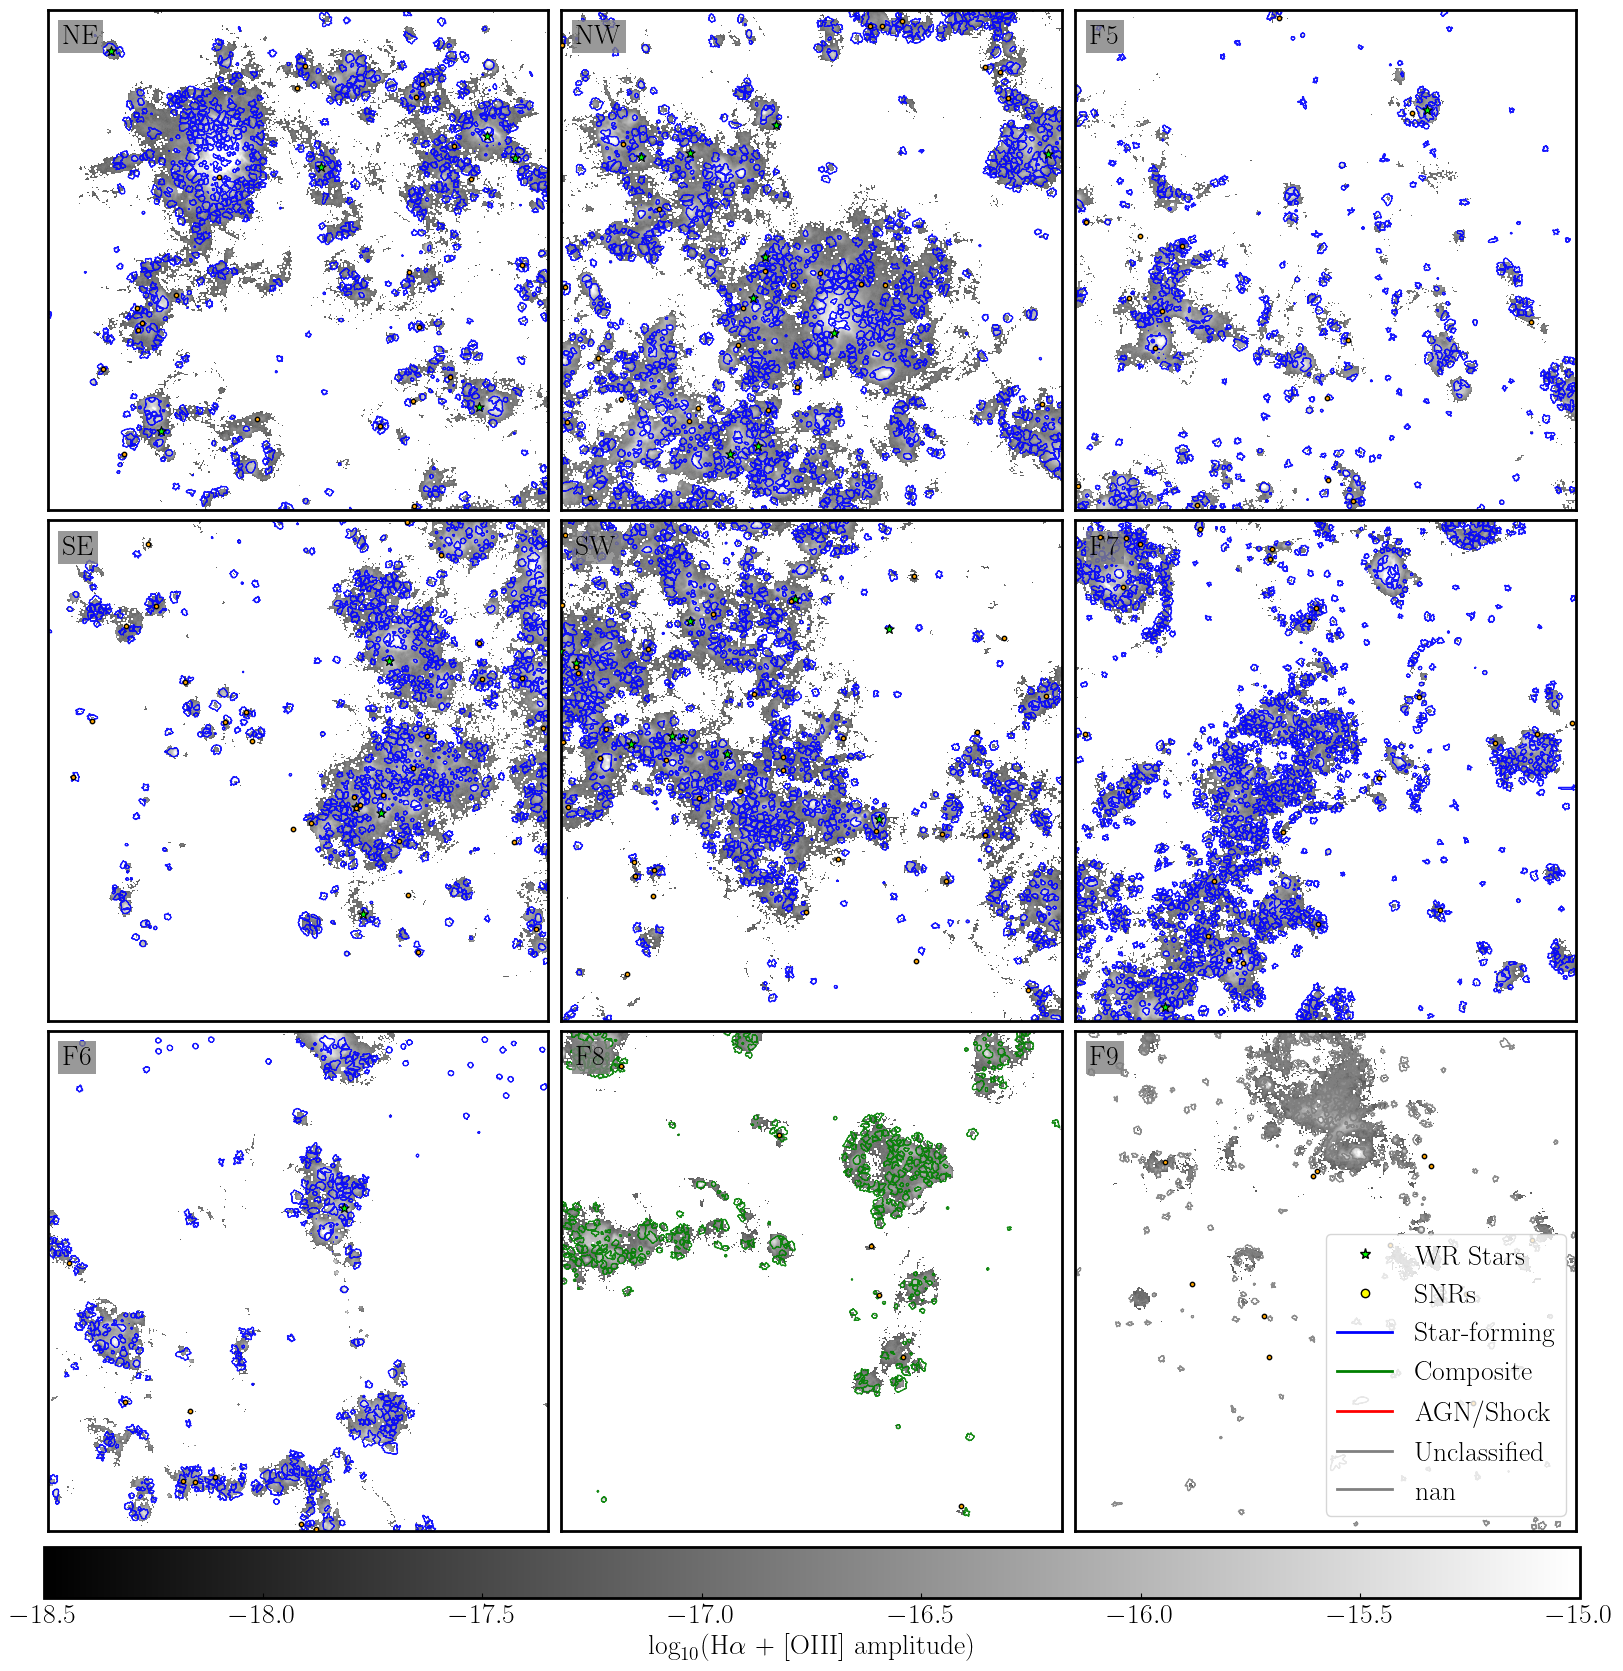

In [ ]:
plot_9_panel=True

# IMPORTANT: set these to match your actual Halpha FITS location and naming
ha_dir = "../M33-Maps"
ha_filename_pattern = "M33-{FIELD}/M33{FIELD}-Haflux.fits" 

haOIII_filename_pattern = "M33-{FIELD}/M33-{FIELD}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits"  # HA+OIII
# If your processed catalogs are named exactly like:
# 'CATALOGS/processed_M33_NW_catalog.csv'
# then set:
catalog_dir = "CATALOGS"
catalog_pattern = "flux_catalogs/flux_catalog_{FIELD}.csv"


if plot_9_panel:
    # plot_m33_9panel_bpt_overlay(
    #     ha_dir=ha_dir,
    #     ha_filename_pattern=haOIII_filename_pattern,
    #     catalog_dir=catalog_dir,
    #     catalog_pattern=catalog_pattern,
    #     wcs_pattern=ha_filename_pattern,  # use Halpha WCS for all panels
    #     boundary_dir="Boundary_maps/Boundary_map_100pc",
    #     field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
    #     xlim=(50, 2000),
    #     ylim=(50, 2000),
    #     cmap = cm.get_cmap("rainbow").copy(),
        
    #     savepath="plots/M33_allfields_9panel_boundary_rainbow.pdf",
    #     plot_peaks = False,
    #     boundary_color="k",
    #     peaks_csv = "CATALOGS/final_peaks_{FIELD}.csv",
    #     plot_boundaries =True
    # )
    
    plot_m33_9panel_bpt_overlay(
        ha_dir=ha_dir,
        ha_filename_pattern=haOIII_filename_pattern,
        catalog_dir=catalog_dir,
        catalog_pattern=catalog_pattern,
        wcs_pattern=ha_filename_pattern,  # use Halpha WCS for all panels
        boundary_dir="Boundary_maps/Boundary_map_100pc",
        field_order=("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9"),
        xlim=(50, 2000),
        ylim=(50, 2000),
        savepath="plots/M33_allfields_9panel_boundary_BPT.pdf",
        plot_peaks = False,
        cmap = cm.get_cmap("grey").copy(),
        color_regions_by="BPT_class_sum_dered",
        categorical_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "grey",
        },
        peaks_csv = "CATALOGS/final_peaks_{FIELD}.csv",
        plot_boundaries =True
    )


In [45]:
def plot_bpt(df,
             x_col='log_NII_Ha_sum_dered',
             x_col_err='log_NII_Ha_sum_dered_err',
             y_col='log_OIII_Hb_sum_dered',
             y_col2 = 'log_SII_Ha_sum_dered',
             class_col='BPT_class_sum_dered',
             snr_cut=3.0,
             figsize=(14, 6),
             savepath=None,
             color_col=None,                 # e.g. 'surface_brightness', 'Rgal', etc.
             cmap='viridis',                 # colormap name or Colormap
             vmin=None, vmax=None,           # color scaling; None => inferred from data
             colorbar=True,
             colorbar_label=None,
             colorbar_log=False,             # True => log-normalize color scale
             missing_color='lightgray'        # used if some points have NaN color_col
            ):
    """
    Plot BPT diagrams:
      LEFT:  [NII]/Ha vs [OIII]/Hb
      RIGHT: [SII]/Ha vs [OIII]/Hb

    Classification is shown via marker shape (and legend).
    If color_col is provided, point facecolor is mapped to that column (with optional colorbar).
    """

    df = df.copy()

    # ---------------------------------------------------
    # Apply SNR cut
    # ---------------------------------------------------
    snr_cols = [f'SNR_{line}_sum' for line in ['Halpha', 'Hbeta', '[NII]6583', '[OIII]5007', '[SII]6731']]
    if all(col in df.columns for col in snr_cols):
        mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            mask &= df[col] >= snr_cut
        df = df[mask]
    else:
        print("Warning: SNR columns not found; skipping SNR cut.")

    # ---------------------------------------------------
    # Compute log ratios if missing
    # ---------------------------------------------------
    # if 'log_NII_Ha' not in df.columns:
    #     df['log_NII_Ha'] = np.log10(df[nii_col] / df[ha_col])

    # if 'log_SII_Ha' not in df.columns:
    #     df['log_SII_Ha'] = np.log10(df[sii_col] / df[ha_col])

    # if 'log_OIII_Hb' not in df.columns:
    #     df['log_OIII_Hb'] = np.log10(df[oiii_col] / df[hb_col])

    # ---------------------------------------------------
    # Error propagation
    # # ---------------------------------------------------
    # # --- NII/Ha ---
    # R_NII_Ha = df[nii_col] / df[ha_col]
    # R_NII_Ha_e = R_NII_Ha * np.sqrt(
    #     (df[nii_e_col] / df[nii_col])**2 +
    #     (df[ha_e_col] / df[ha_col])**2
    # )
    # xerr_nii = (1 / np.log(10)) * (R_NII_Ha_e / R_NII_Ha)

    # # --- SII/Ha ---
    # R_SII_Ha = df[sii_col] / df[ha_col]
    # R_SII_Ha_e = R_SII_Ha * np.sqrt(
    #     (df[sii_e_col] / df[sii_col])**2 +
    #     (df[ha_e_col] / df[ha_col])**2
    # )
    # xerr_sii = (1 / np.log(10)) * (R_SII_Ha_e / R_SII_Ha)

    # # --- OIII/Hb ---
    # R_OIII_Hb = df[oiii_col] / df[hb_col]
    # R_OIII_Hb_e = R_OIII_Hb * np.sqrt(
    #     (df[oiii_e_col] / df[oiii_col])**2 +
    #     (df[hb_e_col] / df[hb_col])**2
    # )
    # yerr = (1 / np.log(10)) * (R_OIII_Hb_e / R_OIII_Hb)

    # ---------------------------------------------------
    # Classification styling
    # ---------------------------------------------------
    # (Used when color_col is None; otherwise shapes carry class info and colorbar carries color_col info)
    default_cmap = plt.cm.magma
    class_colors = {
        'Star-forming': 'blue',
        'Composite': 'green',
        'AGN/Shock': 'red',
        # 'Unclassified': 'grey',
    }

    shapes = {
        'Star-forming': 'o',
        'Composite': '^',
        'AGN/Shock': 's',
        # 'Unclassified': 'x',
    }

    # ---------------------------------------------------
    # Color mapping setup (if requested)
    # ---------------------------------------------------
    use_third_color = (color_col is not None) and (color_col in df.columns)

    norm = None
    sm = None
    if use_third_color:
        cvals_all = df[color_col].to_numpy()
        finite = np.isfinite(cvals_all)

        if vmin is None:
            vmin = np.nanmin(cvals_all[finite]) if np.any(finite) else 0.0
        if vmax is None:
            vmax = np.nanmax(cvals_all[finite]) if np.any(finite) else 1.0

        if colorbar_log:
            # avoid <=0 for LogNorm
            good = cvals_all[finite]
            good = good[good > 0]
            if good.size == 0:
                raise ValueError(f"colorbar_log=True but {color_col} has no positive finite values.")
            if vmin <= 0:
                vmin = np.nanmin(good)
            norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
        else:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        cmap_obj = mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)

    # ---------------------------------------------------
    # Figure setup
    # ---------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # ---------------------------------------------------
    # LEFT: [NII]/Ha BPT
    # ---------------------------------------------------
    x_vals = np.linspace(-2, 1.0, 400)
    kewley_y = 0.61 / (x_vals - 0.47) + 1.19
    kauff_y  = 0.61 / (x_vals - 0.05) + 1.3

    for cls in shapes.keys():
        subset = df[df[class_col] == cls]
        if len(subset) == 0:
            continue

        # errorbars in gray (no markers)
        ax1.errorbar(subset['log_NII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                     xerr=subset['log_NII_Ha_err_sum_dered'],
                     yerr=subset['log_OIII_Hb_err_sum_dered'],
                     fmt='none', ecolor='lightgray',
                     elinewidth=0.8, capsize=1.5, zorder=1)

        # markers: either class color OR third-parameter color
        if use_third_color:
            cvals = subset[color_col].to_numpy()
            ok = np.isfinite(cvals)
            # valid colored points
            ax1.scatter(subset.loc[ok, 'log_NII_Ha_sum_dered'], subset.loc[ok, 'log_OIII_Hb_sum_dered'],
                        c=cvals[ok], cmap=sm.cmap, norm=sm.norm,
                        marker=shapes[cls], s=25, alpha=1.0,
                        edgecolors='none', zorder=2, label=cls)
            # missing colored points
            if np.any(~ok):
                ax1.scatter(subset.loc[~ok, 'log_NII_Ha_sum_dered'], subset.loc[~ok, 'log_OIII_Hb_sum_dered'],
                            c=missing_color, marker=shapes[cls], s=25, alpha=1.0,
                            edgecolors='none', zorder=2, label=None)
        else:
            ax1.scatter(subset['log_NII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                        c=class_colors.get(cls, 'k'),
                        marker=shapes[cls], s=25, alpha=1.0,
                        edgecolors='none', zorder=2, label=cls)

    ax1.plot(x_vals, kauff_y, 'k--', lw=1.5, label='Kauffmann+03')
    ax1.plot(x_vals, kewley_y, 'k-',  lw=1.5, label='Kewley+01')

    ax1.set_xlim(-1.75, 0.5)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_xlabel(r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$')
    ax1.set_ylabel(r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$')
    ax1.legend(frameon=False, loc='lower left', fontsize=10)

    # ---------------------------------------------------
    # RIGHT: [SII]/Ha BPT
    # ---------------------------------------------------
    x_vals_sii = np.linspace(-2, 0.5, 400)
    kewley_sii = 0.72 / (x_vals_sii - 0.32) + 1.30

    for cls in shapes.keys():
        subset = df[df[class_col] == cls]
        if len(subset) == 0:
            continue

        ax2.errorbar(subset['log_SII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                     xerr=subset['log_SII_Ha_err_sum_dered'],
                     yerr=subset['log_OIII_Hb_err_sum_dered'],
                     fmt='none', ecolor='lightgray',
                     elinewidth=0.8, capsize=1.5, zorder=1)

        if use_third_color:
            cvals = subset[color_col].to_numpy()
            ok = np.isfinite(cvals)
            ax2.scatter(subset.loc[ok, 'log_SII_Ha_sum_dered'], subset.loc[ok, 'log_OIII_Hb_sum_dered'],
                        c=cvals[ok], cmap=sm.cmap, norm=sm.norm,
                        marker=shapes[cls], s=25, alpha=1.0,
                        edgecolors='none', zorder=2)
            if np.any(~ok):
                ax2.scatter(subset.loc[~ok, 'log_SII_Ha_sum_dered'], subset.loc[~ok, 'log_OIII_Hb_sum_dered'],
                            c=missing_color, marker=shapes[cls], s=25, alpha=1.0,
                            edgecolors='none', zorder=2)
        else:
            ax2.scatter(subset['log_SII_Ha_sum_dered'], subset['log_OIII_Hb_sum_dered'],
                        c=class_colors.get(cls, 'k'),
                        marker=shapes[cls], s=25, alpha=1.0,
                        edgecolors='none', zorder=2)

    ax2.plot(x_vals_sii, kewley_sii, 'k-', lw=1.5, label='Kewley+01')

    ax2.set_xlim(-1.75, 0.5)
    ax2.set_ylim(-1.5, 1.5)
    ax2.set_xlabel(r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$')
    ax2.set_ylabel(r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$')

    # ticks/spines styling
    ax1.minorticks_on()
    ax2.minorticks_on()
    ax2.tick_params(direction='in', which='both')
    ax1.tick_params(direction='in', which='both')

    for spine in ax1.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")
    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    # ---------------------------------------------------
    # Shared colorbar (if requested)
    # ---------------------------------------------------
    if use_third_color and colorbar and sm is not None:
        cax = fig.add_axes([0.99, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(sm, cax=cax)

        if colorbar_label is None:
            colorbar_label = color_col
        cbar.set_label(colorbar_label)

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, (ax1, ax2)


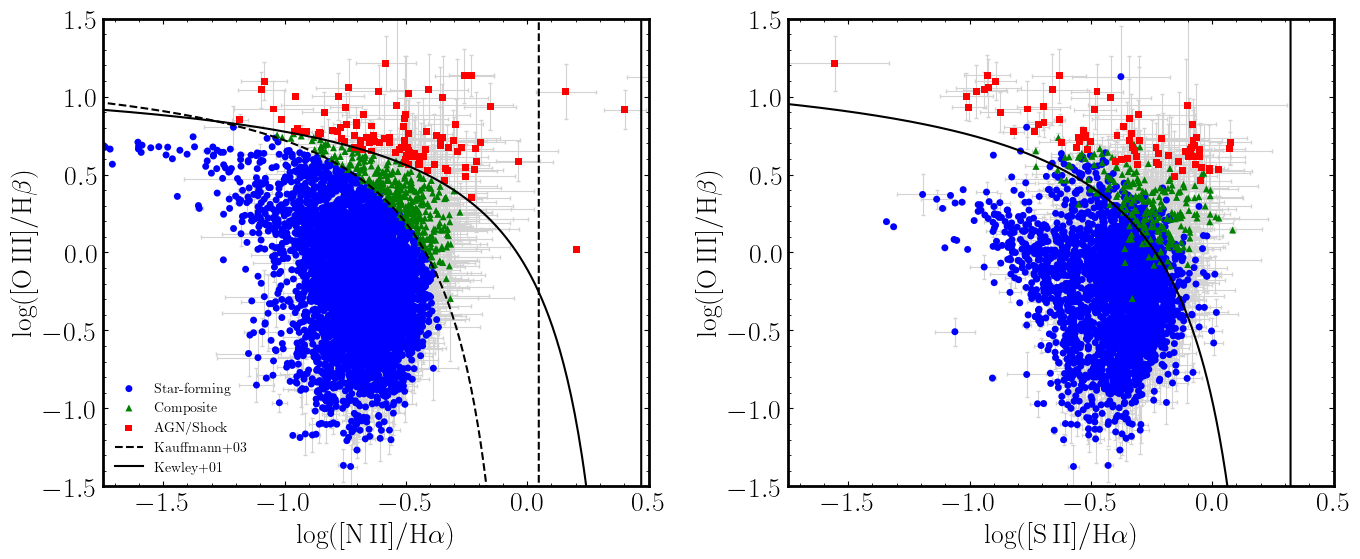

(<Figure size 1400x600 with 2 Axes>,
 (<Axes: xlabel='$\\log([\\mathrm{N\\,II}]/\\mathrm{H}\\alpha)$', ylabel='$\\log([\\mathrm{O\\,III}]/\\mathrm{H}\\beta)$'>,
  <Axes: xlabel='$\\log([\\mathrm{S\\,II}]/\\mathrm{H}\\alpha)$', ylabel='$\\log([\\mathrm{O\\,III}]/\\mathrm{H}\\beta)$'>))

In [29]:
snr_cut=3
plot_bpt(cat, snr_cut=snr_cut, 
         savepath = f'plots/M33_allfields_BPT_SNR{snr_cut}.png')

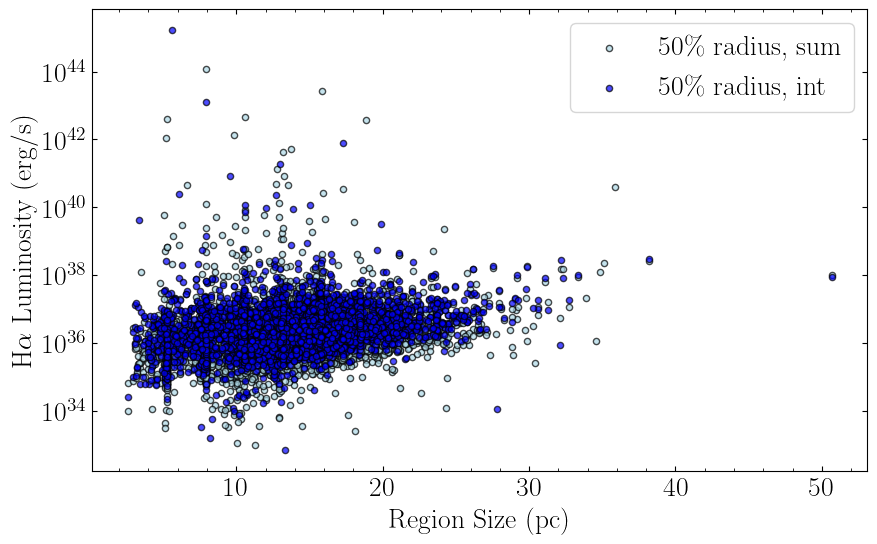

In [35]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
# plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'84\% radius')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightblue', label = r'50\% radius, sum')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'blue', label = r'50\% radius, int')

# plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightgreen', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

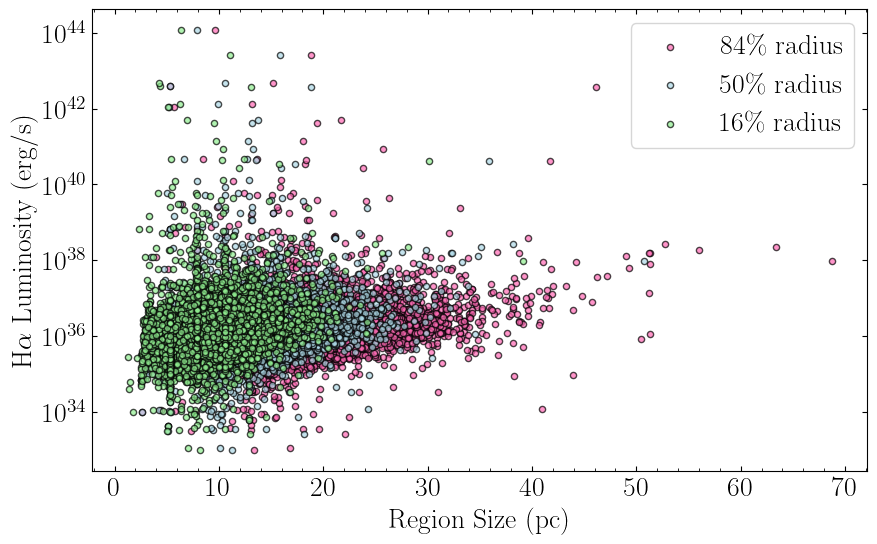

In [ ]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'84\% radius')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightblue', label = r'50\% radius')
plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_sum_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightgreen', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

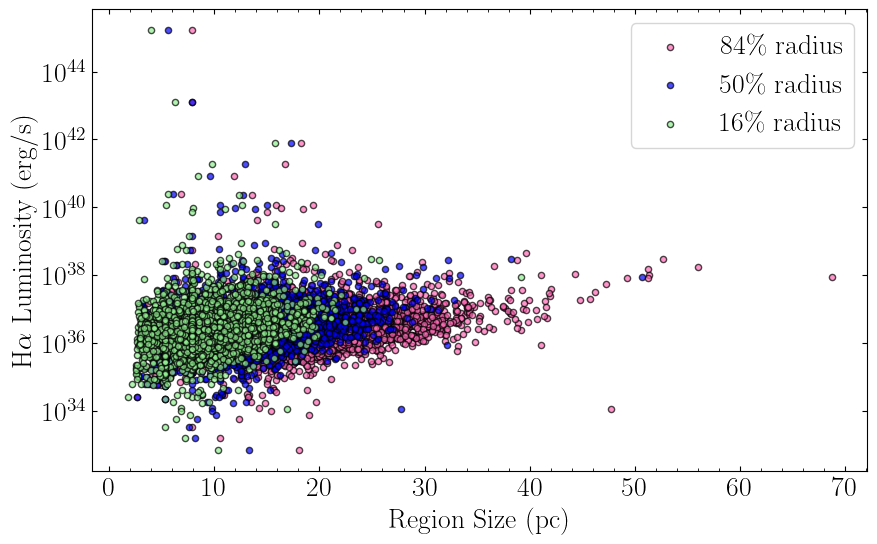

In [38]:
# plot radius vs luminosity
#don't include regions with tiny radius
mask = (cat['radius_p16_pc'] > 1) & (cat['radius_p50_pc'] > 1) & (cat['radius_p84_pc'] > 1)

plt.figure(figsize=(10, 6))
plt.scatter(cat['radius_p84_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'hotpink', label = r'84\% radius')
plt.scatter(cat['radius_p50_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'blue', label = r'50\% radius')
plt.scatter(cat['radius_p16_pc'][mask], cat['L_Ha_int_dered'][mask], s=20, alpha=0.7, edgecolor='k', color = 'lightgreen', label = r'16\% radius')
plt.yscale('log')
plt.xlabel('Region Size (pc)')
plt.ylabel(r'H$\alpha$ Luminosity (erg/s)')
plt.minorticks_on()
plt.legend()
plt.savefig('plots/M33_HII_luminosity_vs_radius.png', dpi=300, bbox_inches='tight')
plt.show()

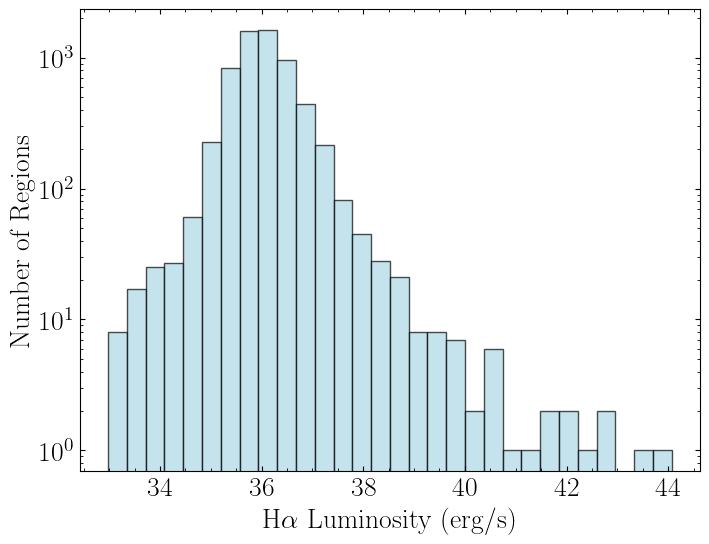

In [39]:
# plot the luminosity function
plt.figure(figsize=(8, 6))
plt.hist(np.log10(cat['L_Ha_sum_dered']), bins=30, color='lightblue', edgecolor='k', alpha = 0.7)
plt.xlabel(r'H$\alpha$ Luminosity (erg/s)')
plt.ylabel('Number of Regions')
plt.yscale('log')
plt.minorticks_on()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.savefig('plots/M33_HII_luminosity_function.png', dpi=300, bbox_inches='tight')
plt.show()